# **1. Perkenalan Dataset**


**Nama:** Muhammad-Febrilian-Kurnia-Putra  
**Username Dicoding:** febril_putra  
**Dataset:** IBM Telco Customer Churn; klasifikasi `Churn` (Yes = 1, No = 0).

```text
Eksperimen Telco
|
+-- 1. Perkenalan dataset -- masalah retensi pelanggan dan sumber data
+-- 2. Import library    -- lingkungan yang dapat dijalankan ulang
+-- 3. Memuat dataset    -- validasi sumber, skema, dan pembagian data
+-- 4. EDA               -- kualitas data dan pola pada data training
`-- 5. Preprocessing     -- transformasi yang dipelajari hanya dari training
```

Perusahaan telekomunikasi dapat memakai probabilitas churn untuk memprioritaskan
peninjauan retensi. Notebook ini menyiapkan data snapshot untuk eksperimen klasifikasi;
dataset tidak menyediakan urutan waktu yang cukup untuk membuktikan kemampuan prediksi
pelanggan masa depan secara prospektif. Hasilnya merupakan evaluasi pada holdout acak.

Data berasal dari [repository resmi IBM](https://github.com/IBM/telco-customer-churn-on-icp4d),
berkas `data/Telco-Customer-Churn.csv` pada commit
`d5371f5d83a446ad5673cbcca3b814b926491f8a`. Salinan lokal dan lisensi repository IBM
tersedia di `../telco_churn_raw/`. Identitas sumber dibekukan dengan SHA-256.
Tidak diperlukan akun Kaggle maupun layanan berbayar.

| Komponen | Pemakaian |
| --- | --- |
| `customerID` | Validasi keunikan dan pemisahan pelanggan; dikeluarkan dari fitur |
| `Churn` | Target biner; tidak ikut dalam transformasi fitur |
| Numerik | SeniorCitizen, tenure, MonthlyCharges, TotalCharges |
| Kategorikal | 15 atribut layanan, kontrak, pembayaran, dan demografi |
| Pemodelan selanjutnya | Random Forest baseline dan tuning; Average Precision sebagai metrik seleksi |

Lima bagian utama dipertahankan dari Template Eksperimen MSML. Semua langkah
loading, EDA, dan transformasi di bawah dijalankan secara manual di notebook.

# **2. Import Library**

In [1]:
from pathlib import Path
import hashlib
import importlib.util
import json
import platform
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

SEED = 42
sns.set_theme(style='whitegrid', palette='colorblind')
pd.set_option('display.max_columns', 25)
print({'python': platform.python_version(), 'pandas': pd.__version__,
       'numpy': np.__version__, 'scikit-learn': sklearn.__version__})

{'python': '3.12.10', 'pandas': '2.2.3', 'numpy': '1.26.4', 'scikit-learn': '1.5.2'}


# **3. Memuat Dataset**

In [2]:
# Dapat dijalankan dari root repository atau dari folder preprocessing.
REPO = next((path for path in [Path.cwd(), *Path.cwd().parents]
             if (path / 'telco_churn_raw/Telco-Customer-Churn.csv').is_file()), None)
assert REPO is not None, 'Jalankan notebook dari checkout repository eksperimen.'
raw_path = REPO / 'telco_churn_raw/Telco-Customer-Churn.csv'
source_sha = hashlib.sha256(raw_path.read_bytes()).hexdigest()
assert source_sha == '16320c9c1ec72448db59aa0a26a0b95401046bef5d02fd3aeb906448e3055e91'
raw = pd.read_csv(raw_path, dtype={'customerID': str, 'TotalCharges': str})
print('Dimensi:', raw.shape, '| SHA-256:', source_sha)
display(raw.head())
display(raw.dtypes.rename('tipe_data').to_frame())

Dimensi: (7043, 21) | SHA-256: 16320c9c1ec72448db59aa0a26a0b95401046bef5d02fd3aeb906448e3055e91


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,tipe_data
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [3]:
# Pemeriksaan integritas sumber. Statistik transformasi belum dipelajari di sini.
for column in raw.select_dtypes(include='object'):
    raw[column] = raw[column].str.strip()
assert raw.shape == (7043, 21)
assert raw.customerID.notna().all() and raw.customerID.ne('').all()
assert raw.customerID.is_unique
assert set(raw.Churn.unique()) == {'No', 'Yes'}
print('Baris duplikat:', raw.duplicated().sum())
print('TotalCharges kosong:', raw.TotalCharges.eq('').sum())

# Kunci test sebelum EDA. Gunakan train untuk keputusan preprocessing.
train, holdout = train_test_split(raw, test_size=0.30, stratify=raw.Churn, random_state=SEED)
val, test = train_test_split(holdout, test_size=0.50, stratify=holdout.Churn, random_state=SEED)
splits = {'train': train, 'val': val, 'test': test}
for left, right in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
    assert set(splits[left].customerID).isdisjoint(splits[right].customerID)
display(pd.DataFrame({name: {'baris': len(frame), 'churn': int(frame.Churn.eq('Yes').sum()),
                             'proporsi_churn': frame.Churn.eq('Yes').mean()}
                      for name, frame in splits.items()}).T)

Baris duplikat: 0
TotalCharges kosong: 11


,baris,churn,proporsi_churn
train,4930.0,1308.0,0.265314
val,1056.0,280.0,0.265152
test,1057.0,281.0,0.265847


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

EDA berikut menggunakan bagian training. Distribusi label antar-split di atas hanya
memeriksa keberhasilan stratifikasi; validation dipakai nanti untuk memilih model,
sedangkan test dipakai setelah konfigurasi model dikunci. `TotalCharges` terbaca
sebagai teks karena mengandung spasi. Kita memeriksa hubungannya dengan tenure
sebelum menetapkan aturan pengisian.

,missing,unik
customerID,0,4930
gender,0,2
SeniorCitizen,0,2
Partner,0,2
Dependents,0,2
tenure,0,73
PhoneService,0,2
MultipleLines,0,3
InternetService,0,3
OnlineSecurity,0,3


,tenure,MonthlyCharges,TotalCharges
6670,0,73.35,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
488,0,52.55,NaN
1082,0,25.75,NaN
6754,0,61.90,NaN
3331,0,19.85,NaN


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,4930.0,0.161055,0.367619,0.00,0.0,0.000,0.00,1.00
tenure,4930.0,32.471197,24.646350,0.00,9.0,29.000,56.00,72.00
MonthlyCharges,4930.0,64.950081,30.243674,18.40,35.5,70.575,90.05,118.75
TotalCharges,4923.0,2305.070485,2292.550954,18.85,399.8,1389.200,3860.30,8684.80


,jumlah
Churn,
No,3622
Yes,1308


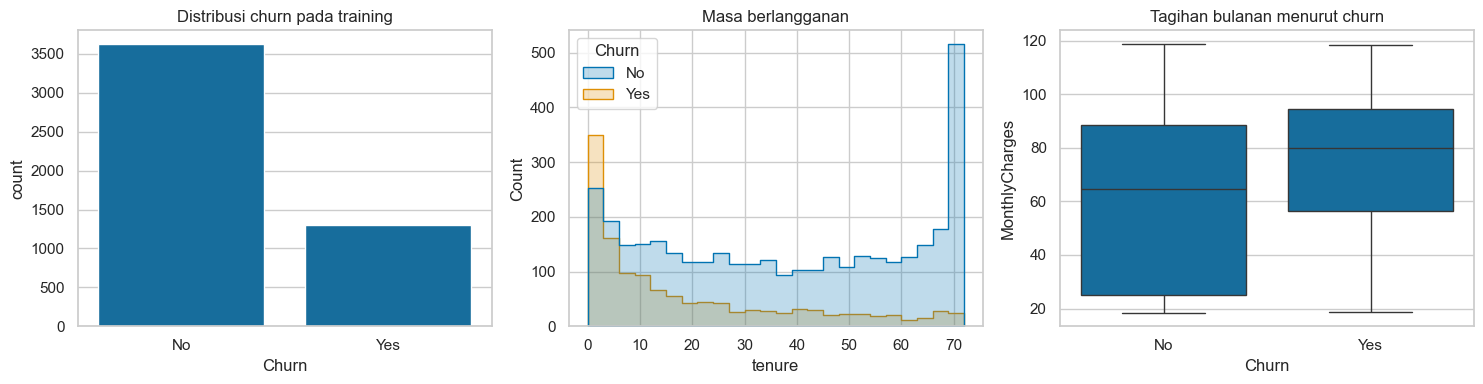

In [4]:
NUMERIC = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
RAW_FEATURES = raw.columns.drop(['customerID', 'Churn']).tolist()
CATEGORICAL = [column for column in RAW_FEATURES if column not in NUMERIC]
eda = train.copy()
eda['TotalCharges'] = pd.to_numeric(eda.TotalCharges, errors='coerce')
quality = pd.DataFrame({'missing': eda.isna().sum(), 'unik': eda.nunique()})
display(quality)
display(eda.loc[eda.TotalCharges.isna(), ['tenure', 'MonthlyCharges', 'TotalCharges']])
display(eda[NUMERIC].describe().T)
display(eda.Churn.value_counts().rename_axis('Churn').to_frame('jumlah'))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=eda, x='Churn', order=['No', 'Yes'], ax=axes[0])
axes[0].set_title('Distribusi churn pada training')
sns.histplot(data=eda, x='tenure', hue='Churn', bins=24, element='step', ax=axes[1])
axes[1].set_title('Masa berlangganan')
sns.boxplot(data=eda, x='Churn', y='MonthlyCharges', ax=axes[2])
axes[2].set_title('Tagihan bulanan menurut churn')
plt.tight_layout()
plt.show()

,pelanggan,proporsi_churn
Contract,,
Month-to-month,2704,0.428624
One year,1034,0.109284
Two year,1192,0.030201


,Male,Female,No,Yes,No phone service,Fiber optic,DSL,No internet service,Month-to-month,Two year,One year,Electronic check,Mailed check,Bank transfer (automatic),Credit card (automatic)
gender,2478.0,2452.0,,,,,,,,,,,,,
Partner,,,2558.0,2372.0,,,,,,,,,,,
Dependents,,,3463.0,1467.0,,,,,,,,,,,
PhoneService,,,496.0,4434.0,,,,,,,,,,,
MultipleLines,,,2347.0,2087.0,496.0,,,,,,,,,,
InternetService,,,1068.0,,,2177.0,1685.0,,,,,,,,
OnlineSecurity,,,2439.0,1423.0,,,,1068.0,,,,,,,
OnlineBackup,,,2142.0,1720.0,,,,1068.0,,,,,,,
DeviceProtection,,,2140.0,1722.0,,,,1068.0,,,,,,,
TechSupport,,,2411.0,1451.0,,,,1068.0,,,,,,,


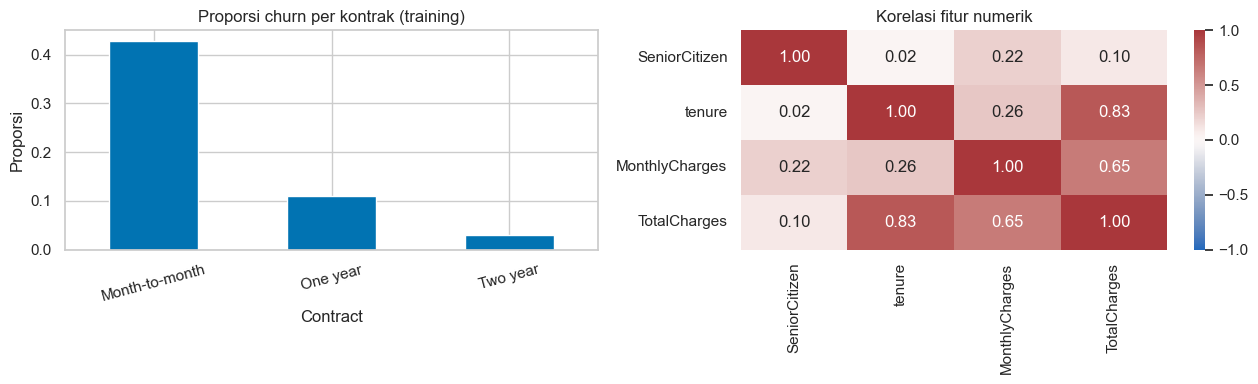

,jumlah_di_luar_IQR
SeniorCitizen,794
tenure,0
MonthlyCharges,0
TotalCharges,0


Pada training terdapat **4,930 pelanggan**, dengan proporsi churn **26.53%**. Semua **7** TotalCharges kosong pada training memiliki tenure=0: **True**. Ini mendukung aturan nilai awal TotalCharges=0 untuk pelanggan tersebut. Perbedaan proporsi antar-kontrak merupakan asosiasi, bukan bukti sebab-akibat.

In [5]:
contract_summary = eda.groupby('Contract', observed=True).agg(
    pelanggan=('Churn', 'size'), proporsi_churn=('Churn', lambda values: values.eq('Yes').mean()))
display(contract_summary)
display(pd.DataFrame({column: eda[column].value_counts().to_dict() for column in CATEGORICAL}).T.fillna(''))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
contract_summary.proporsi_churn.plot.bar(ax=axes[0], rot=15)
axes[0].set(title='Proporsi churn per kontrak (training)', ylabel='Proporsi')
sns.heatmap(eda[NUMERIC].corr(), annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Korelasi fitur numerik')
plt.tight_layout()
plt.show()

q1, q3 = eda[NUMERIC].quantile(0.25), eda[NUMERIC].quantile(0.75)
iqr = q3 - q1
display(((eda[NUMERIC] < q1 - 1.5 * iqr) | (eda[NUMERIC] > q3 + 1.5 * iqr))
        .sum().rename('jumlah_di_luar_IQR').to_frame())
display(Markdown(f"Pada training terdapat **{len(train):,} pelanggan**, dengan proporsi churn "
                 f"**{train.Churn.eq('Yes').mean():.2%}**. Semua **{eda.TotalCharges.isna().sum()}** "
                 f"TotalCharges kosong pada training memiliki tenure=0: "
                 f"**{eda.loc[eda.TotalCharges.isna(), 'tenure'].eq(0).all()}**. "
                 "Ini mendukung aturan nilai awal TotalCharges=0 untuk pelanggan tersebut. "
                 "Perbedaan proporsi antar-kontrak merupakan asosiasi, bukan bukti sebab-akibat."))

# **5. Data Preprocessing**

| Keputusan | Alasan |
| --- | --- |
| Pisahkan train/validation/test sebelum fit | Mencegah median, modus, dan kategori dipelajari dari holdout |
| Buang customerID dari fitur | ID hanya digunakan untuk pemeriksaan keunikan |
| Bersihkan spasi; konversi TotalCharges menjadi numerik | Menangani nilai kosong yang tersembunyi; nilai nonnumerik yang tidak kosong ditolak |
| TotalCharges kosong dan tenure=0 diisi 0 | Asumsi domain yang didukung pemeriksaan training; dicatat untuk konsistensi inferensi |
| Missing numerik lainnya diisi median training | Fallback konsisten untuk data baru |
| Missing kategori diisi modus training; one-hot encoding | Tidak menganggap kategori layanan sebagai angka berurutan; kategori baru ditangani tanpa crash |
| Pertahankan No internet service / No phone service | Menandakan layanan tidak tersedia, bukan missing value |
| Tanpa scaling dan binning | Random Forest tidak memerlukan skala fitur yang setara; binning mengurangi informasi numerik |
| Tidak membuang outlier otomatis | Pelanggan dengan tagihan/tenure tinggi masih bermakna; batas IQR bukan bukti kesalahan |
| Tanpa oversampling sebelum split | Jaga holdout alami; class_weight akan diuji hanya dalam tuning |

```text
CSV -> validasi -> split 70/15/15 -> pembersihan dengan aturan tetap
                                     |
                 train -> fit median/modus/encoder -> simpan transformer
                                     |
                 val/test --------> transform saja -> CSV + manifest
```

In [6]:
# Transformasi manual: semua keputusan eksplisit terlihat di notebook.
clean = {}
for name, frame in splits.items():
    features = frame.loc[:, RAW_FEATURES].copy()
    for column in CATEGORICAL:
        features[column] = features[column].astype('string').str.strip()
        features[column] = features[column].replace('', pd.NA).astype(object)
        features[column] = features[column].where(pd.notna(features[column]), np.nan)
    for column in NUMERIC:
        before = features[column]
        parsed = pd.to_numeric(before, errors='coerce')
        invalid = parsed.isna() & before.notna() & before.astype(str).str.strip().ne('')
        assert not invalid.any(), f'Nilai nonnumerik tidak dikenal: {column}'
        features[column] = parsed
    zero_tenure = features.TotalCharges.isna() & features.tenure.eq(0)
    features.loc[zero_tenure, 'TotalCharges'] = 0.0
    clean[name] = features

preprocessor = ColumnTransformer([
    ('numeric', Pipeline([('imputer', SimpleImputer(strategy='median'))]), NUMERIC),
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float64)),
    ]), CATEGORICAL),
], verbose_feature_names_out=False)
matrices = {'train': preprocessor.fit_transform(clean['train'])}
matrices.update({name: preprocessor.transform(clean[name]) for name in ['val', 'test']})
names = preprocessor.get_feature_names_out().tolist()
assert 'customerID' not in names and 'Churn' not in names
assert all(np.isfinite(matrix).all() for matrix in matrices.values())
np.testing.assert_allclose(preprocessor.named_transformers_['numeric'].named_steps['imputer'].statistics_,
                           clean['train'][NUMERIC].median().to_numpy())
display(pd.DataFrame(matrices['train'], columns=names).head())
print('Dimensi hasil:', {name: matrix.shape for name, matrix in matrices.items()})

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,5.0,80.20,384.25,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,3.0,86.85,220.95,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,3.0,75.15,216.75,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0.0,60.0,80.55,4847.05,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.0,12.0,98.90,1120.95,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


Dimensi hasil: {'train': (4930, 45), 'val': (1056, 45), 'test': (1057, 45)}


In [7]:
# Helper ini hanya menulis CSV/transformer/manifest; loading, split, dan fit sudah
# dilakukan manual di atas. Automasi memakai kontrak ekspor yang sama.
spec = importlib.util.spec_from_file_location('automate', REPO / 'preprocessing/automate_Muhammad-Febrilian-Kurnia-Putra.py')
automation = importlib.util.module_from_spec(spec)
spec.loader.exec_module(automation)
output_dir = REPO / 'preprocessing/telco_churn_preprocessing'
manifest = automation.export_results(raw_path, splits, matrices, preprocessor, output_dir, SEED)
display(pd.DataFrame({name: {key: value for key, value in info.items() if key != 'customer_ids'}
                      for name, info in manifest['splits'].items()}).T)
print('Fit scope:', manifest['fit_scope'])
print('Berkas hasil:', sorted(manifest['files']))
assert sum(info['rows'] for info in manifest['splits'].values()) == len(raw)

,rows,encoded_columns,positive_count
train,4930,45,1308
val,1056,45,280
test,1057,45,281


Fit scope: training split only
Berkas hasil: ['X_test.csv', 'X_train.csv', 'X_val.csv', 'example_encoded.json', 'example_raw.json', 'feature_schema.json', 'preprocessor.joblib', 'y_test.csv', 'y_train.csv', 'y_val.csv']


**Hasil dan kelanjutan:** data numerik siap dilatih, transformer, skema fitur,
contoh payload, serta manifest checksum tersimpan di `telco_churn_preprocessing/`.
Script `automate_Muhammad-Febrilian-Kurnia-Putra.py` mengemas langkah yang sama
menjadi fungsi dan CLI. Workflow GitHub Actions menjalankan pengujian integritas,
menghasilkan ulang preprocessing, lalu mengunggah hasil sebagai artefak run.
Keberhasilan eksekusi lokal notebook tidak berarti workflow online sudah berhasil.

Model berikutnya memakai Average Precision untuk seleksi pada validation karena
kelas churn lebih sedikit; ROC-AUC, F1, precision, recall, dan accuracy tetap dilaporkan.
Test tidak digunakan untuk memilih parameter atau threshold (threshold dikunci 0,5).

**Key Concepts — Summary**

| Term | Definition |
| --- | --- |
| Churn | Pelanggan berhenti berlangganan; kelas positif bernilai 1 |
| Data leakage | Informasi holdout ikut memengaruhi proses belajar |
| Fit/transform | Statistik dipelajari pada training, kemudian diterapkan ke data lain |
| Stratifikasi | Mempertahankan proporsi kelas saat membagi data |
| Manifest | Catatan asal data, pelanggan tiap split, dan checksum hasil |

> Pipeline yang dapat diulang memerlukan pembagian data, aturan pembersihan, dan transformer yang konsisten sejak eksperimen hingga inferensi.